##Twitter Bot Detection using Graph Neural Networks (GraphSAGE)

###Environment Setup

Install PyTorch Geometric dependencies and streaming JSON parser required for large-scale graph and tweet data processing.

In [ ]:
!pip install torch-geometric pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
-f https://data.pyg.org/whl/torch-2.2.0+cu118.html

!pip install ijson

###Imports and Reproducibility

Import all required libraries and ensure reproducibility by fixing random seeds across NumPy and PyTorch.

In [2]:
import os, gc, json, ijson, random
import numpy as np
import pandas as pd
from datetime import datetime
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/libpyg.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sp

Using device: cpu


###Mount Drive and Data Path

Mount Google Drive and define dataset paths.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/TwitBot"
print(os.listdir(DATA_PATH))

Mounted at /content/drive
['user.json', 'tweet_8.json', 'tweet_7.json', 'tweet_6.json', 'tweet_5.json', 'hashtag.json', 'edge.csv', 'tweet_3.json', 'tweet_4.json', 'tweet_1.json', 'tweet_2.json', 'readme.md', 'tweet_0.json', 'split.csv', 'list.json', 'label.csv', 'cached_graph.pt', 'cached_tweet_stats.pt', 'cached_features.pt', 'Polarization_dataset']


###Load Labels and Sampling

Load labeled dataset, clean duplicates, and create a balanced subset of users.

In [4]:
labels = pd.read_csv(f"{DATA_PATH}/label.csv")
labels = labels.dropna().drop_duplicates("id")

labels["label"] = labels["label"].map({"human":0, "bot":1})

bots = labels[labels["label"]==1]
humans = labels[labels["label"]==0]

N = 5000
core_users = pd.concat([
    bots.sample(N, random_state=SEED),
    humans.sample(N, random_state=SEED)
])

core_ids = set(core_users["id"])
print("Core users:", len(core_ids))

Core users: 10000


###Graph Construction

Construct interaction graph using follower relationships with degree control and caching.**bold text**

In [5]:
GRAPH_CACHE = f"{DATA_PATH}/cached_graph.pt"

if os.path.exists(GRAPH_CACHE):
    saved = torch.load(GRAPH_CACHE)
    kept_edges = saved["kept_edges"]
    nodes = saved["nodes"]
    node_to_idx = saved["node_to_idx"]
else:
    VALID_REL = {"following", "followers"}
    MAX_DEGREE = 35

    degree_counter = defaultdict(int)
    kept_edges = []

    for chunk in pd.read_csv(
        f"{DATA_PATH}/edge.csv",
        chunksize=2_000_000,
        usecols=["source_id","target_id","relation"]
    ):
        chunk = chunk[chunk["relation"].isin(VALID_REL)]

        for s, t in zip(chunk["source_id"], chunk["target_id"]):
            if (s in core_ids) or (t in core_ids):
                if degree_counter[s] < MAX_DEGREE:
                    kept_edges.append((s,t))
                    degree_counter[s]+=1

        del chunk
        gc.collect()

    nodes = sorted(set([s for s,_ in kept_edges] + [t for _,t in kept_edges]))
    node_to_idx = {n:i for i,n in enumerate(nodes)}

    torch.save({
        "kept_edges": kept_edges,
        "nodes": nodes,
        "node_to_idx": node_to_idx
    }, GRAPH_CACHE)

###Edge Tensor

Convert graph edges into PyTorch Geometric format.

In [6]:
edge_index = torch.tensor([
    [node_to_idx[s] for s,t in kept_edges],
    [node_to_idx[t] for s,t in kept_edges]
], dtype=torch.long)

###Tweet Aggregation

Aggregate tweet-level behavioral statistics per user.

In [7]:
def aggregate_tweets(file_path, user_set):
    stats = defaultdict(lambda:{
        "tweet_count":0,"retweet":0,"reply":0,
        "mention":0,"hashtag":0,"url":0,"total_len":0,
        "likes":0,"retweets_count":0,
        "media":0,"sensitive":0,"english":0,
        "sources":defaultdict(int),
        "unique_hashtags":set()
    })

    with open(file_path,"r") as f:
        for tw in ijson.items(f,"item"):
            uid = str(tw.get("author_id"))
            if uid not in user_set: continue

            s = stats[uid]
            s["tweet_count"] += 1
            text = tw.get("text","")
            s["total_len"] += len(text)

            pm = tw.get("public_metrics",{})
            s["likes"] += pm.get("like_count",0)
            s["retweets_count"] += pm.get("retweet_count",0)

            if tw.get("lang") == "en": s["english"] += 1
            if tw.get("possibly_sensitive"): s["sensitive"] += 1
            if tw.get("entities", {}).get("media"): s["media"] += 1

            src = tw.get("source","")
            s["sources"][src] += 1

            for h in tw.get("entities", {}).get("hashtags", []):
                tag = h.get("text","").lower()
                s["unique_hashtags"].add(tag)
                s["hashtag"] += 1

            ent = tw.get("entities", {})
            s["mention"] += len(ent.get("user_mentions",[]))
            s["url"] += len(ent.get("urls",[]))

    return stats

###Tweet Cache

Load or compute tweet statistics using caching for efficiency.

In [8]:
TWEET_CACHE = f"{DATA_PATH}/cached_tweet_stats.pt"

if os.path.exists(TWEET_CACHE):
    tweet_stats = torch.load(TWEET_CACHE)
else:
    tweet_stats = {}

    for i in range(9):
        stats = aggregate_tweets(f"{DATA_PATH}/tweet_{i}.json", core_ids)

        for k,v in stats.items():
            if k not in tweet_stats:
                tweet_stats[k]=v
            else:
                for kk in v:
                    tweet_stats[k][kk]+=v[kk]

        gc.collect()

    torch.save(tweet_stats, TWEET_CACHE)

###Feature Engineering

Generate node-level features combining user metadata and tweet behavior.

In [9]:
def compute_features(user, ts):
    pm = user["public_metrics"]

    followers = pm["followers_count"]
    following = pm["following_count"]
    tweets = pm["tweet_count"]
    listed = pm["listed_count"]

    verified = int(user["verified"])
    protected = int(user["protected"])

    ratio = followers/(following+1)

    log_followers = np.log1p(followers)
    log_following = np.log1p(following)
    log_tweets = np.log1p(tweets)

    created = datetime.fromisoformat(user["created_at"])
    age = (datetime.now(created.tzinfo)-created).days
    tweets_per_day = tweets/(age+1)

    desc = user.get("description") or ""
    desc_len = len(desc)
    has_desc = int(desc_len>0)
    username_len = len(user.get("username",""))

    tcount = ts.get("tweet_count",0)

    ret_ratio = ts.get("retweet",0)/(tcount+1)
    rep_ratio = ts.get("reply",0)/(tcount+1)
    mention_avg = ts.get("mention",0)/(tcount+1)
    hashtag_avg = ts.get("hashtag",0)/(tcount+1)
    url_avg = ts.get("url",0)/(tcount+1)
    avg_len = ts.get("total_len",0)/(tcount+1)

    like_avg = ts.get("likes",0)/(tcount+1)
    retweet_avg = ts.get("retweets_count",0)/(tcount+1)

    english_ratio = ts.get("english",0)/(tcount+1)
    sensitive_ratio = ts.get("sensitive",0)/(tcount+1)
    media_ratio = ts.get("media",0)/(tcount+1)

    hashtag_diversity = len(ts.get("unique_hashtags",[]))/(tcount+1)
    source_diversity = len(ts.get("sources",{}))

    return [
        followers, following, tweets, listed,
        verified, protected,
        ratio, log_followers, log_following, log_tweets,
        age, tweets_per_day,
        desc_len, has_desc, username_len,
        ret_ratio, rep_ratio,
        mention_avg, hashtag_avg, url_avg,
        avg_len, like_avg, retweet_avg,
        english_ratio, sensitive_ratio,
        media_ratio, hashtag_diversity,
        source_diversity
    ]

###Feature Matrix

Construct and normalize feature matrix.

In [10]:
FEATURE_CACHE = f"{DATA_PATH}/cached_features.pt"

if os.path.exists(FEATURE_CACHE):
    X = torch.load(FEATURE_CACHE)
else:
    X_np = np.zeros((len(nodes),28))

    with open(f"{DATA_PATH}/user.json","r") as f:
        for user in ijson.items(f,"item"):
            uid = user["id"]
            if uid in node_to_idx:
                X_np[node_to_idx[uid]] = compute_features(user, tweet_stats.get(uid,{}))

    scaler = StandardScaler()
    X_np = scaler.fit_transform(X_np)

    X = torch.tensor(X_np, dtype=torch.float)
    torch.save(X, FEATURE_CACHE)

###Add Degree Feature

Augment node features with graph degree.

In [11]:
import networkx as nx

G = nx.DiGraph()
G.add_edges_from(kept_edges)

degrees = dict(G.degree())
degree_feature = np.array([degrees.get(n,0) for n in nodes]).reshape(-1,1)

X = torch.cat([X, torch.tensor(degree_feature, dtype=torch.float)], dim=1)

###Labels + Split

Assign labels and perform stratified splitting.

In [12]:
y = torch.full((len(nodes),),-1,dtype=torch.long)

for _,row in core_users.iterrows():
    if row["id"] in node_to_idx:
        y[node_to_idx[row["id"]]]=row["label"]

labeled_idx = (y != -1).nonzero(as_tuple=True)[0].cpu().numpy()
labels_np = y[labeled_idx].cpu().numpy()

train_idx, temp_idx = train_test_split(
    labeled_idx, test_size=0.3, stratify=labels_np, random_state=SEED
)

temp_labels = y[temp_idx].cpu().numpy()

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_labels, random_state=SEED
)

train_mask = torch.zeros(len(nodes), dtype=torch.bool)
val_mask   = torch.zeros(len(nodes), dtype=torch.bool)
test_mask  = torch.zeros(len(nodes), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

###Data Object

Create PyG data object

In [13]:
data = Data(
    x=X,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
).to(device)

###Model

Define GraphSAGE with residual connections and regularization.

In [14]:
class GraphSAGE(nn.Module):
    def __init__(self, in_ch, hidden=256):
        super().__init__()

        self.conv1 = SAGEConv(in_ch, hidden)
        self.bn1 = nn.BatchNorm1d(hidden)

        self.conv2 = SAGEConv(hidden, hidden)
        self.bn2 = nn.BatchNorm1d(hidden)

        self.conv3 = SAGEConv(hidden, hidden)
        self.bn3 = nn.BatchNorm1d(hidden)

        self.layer_norm = nn.LayerNorm(hidden)
        self.dropout = nn.Dropout(0.5)

        self.lin = nn.Linear(hidden, 2)

    def forward(self, x, edge_index):
        x1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        x1 = self.dropout(x1)

        x2 = F.relu(self.bn2(self.conv2(x1, edge_index)))
        x2 = self.dropout(x2)

        x3 = F.relu(self.bn3(self.conv3(x2, edge_index)))
        x3 = self.layer_norm(x3)

        x = x3 + x1
        return self.lin(x)

###Config

Define training configuration.

In [15]:
CONFIG = {
    "lr": 0.002,
    "epochs": 200,
    "patience": 10,
    "gradient_clip": 1.0
}

###Optimizer + Loss

Initialize optimizer and class-balanced loss.

In [16]:
model = GraphSAGE(X.shape[1]).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)

class_counts = torch.bincount(data.y[data.train_mask])
weights = (1.0 / class_counts.float()).to(device)
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)

### Training

Train model with early stopping.

In [17]:
train_losses, val_aucs = [], []
best_auc, counter = 0, 0
best_state, best_probs = None, None

for epoch in range(CONFIG["epochs"]):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["gradient_clip"])
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits, dim=1)[:,1]

        val_auc = roc_auc_score(
            data.y[data.val_mask].cpu(),
            probs[data.val_mask].cpu()
        )

    val_aucs.append(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc
        best_state = model.state_dict()
        best_probs = probs.detach()
        counter = 0
    else:
        counter += 1

    if counter >= CONFIG["patience"]:
        break

model.load_state_dict(best_state)
probs = best_probs

### Threshold Tuning

Optimize threshold using validation F1.

In [18]:
val_probs = probs[data.val_mask].cpu().numpy()
val_true = data.y[data.val_mask].cpu().numpy()

best_thresh, best_f1 = 0.5, 0

for t in np.arange(0.1,0.9,0.01):
    preds = (val_probs > t).astype(int)
    f1 = f1_score(val_true, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

### Final Evaluation

Evaluate final model on test set.

In [19]:
test_probs = probs[data.test_mask].cpu().numpy()
test_true = data.y[data.test_mask].cpu().numpy()

test_preds = (test_probs > best_thresh).astype(int)

print(classification_report(test_true, test_preds))
print("ROC-AUC:", roc_auc_score(test_true, test_probs))

              precision    recall  f1-score   support

           0       0.83      0.70      0.76       529
           1       0.69      0.83      0.75       431

    accuracy                           0.76       960
   macro avg       0.76      0.76      0.76       960
weighted avg       0.77      0.76      0.76       960

ROC-AUC: 0.8524247913368043


### Visualization

Plot training dynamics.

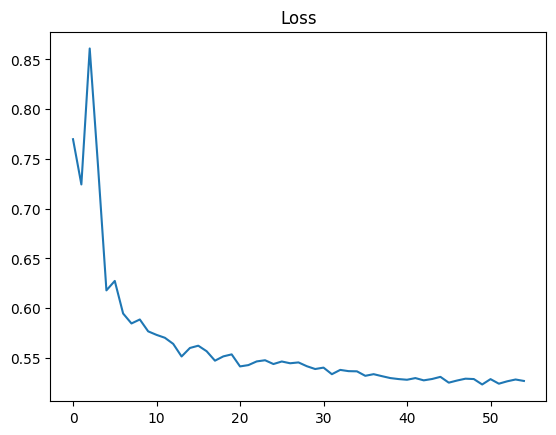

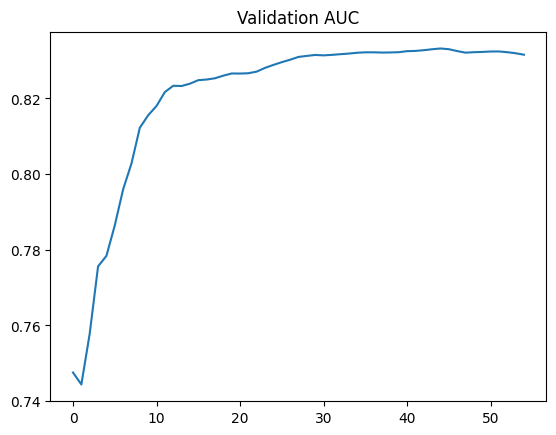

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title("Loss")
plt.show()

plt.plot(val_aucs)
plt.title("Validation AUC")
plt.show()

### Model Comparison

Compare model vs baseline.

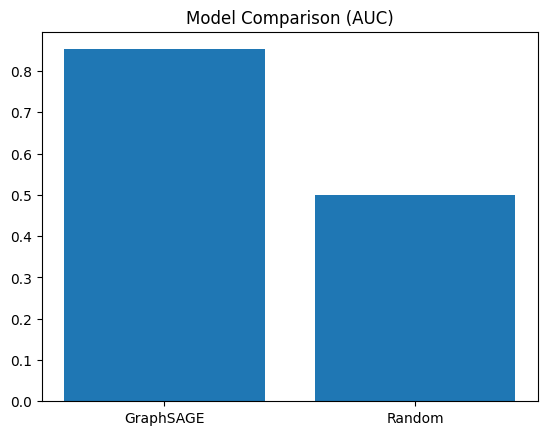

In [21]:
results = {
    "GraphSAGE": roc_auc_score(test_true, test_probs),
    "Random": 0.5
}

plt.bar(results.keys(), results.values())
plt.title("Model Comparison (AUC)")
plt.show()

## GRADIO DASHBOARD

In [ ]:
!pip install gradio

In [27]:
import gradio as gr
import matplotlib.pyplot as plt
import random

model.eval()
with torch.no_grad():
    final_logits = model(data.x, data.edge_index)
    final_probs = F.softmax(final_logits, dim=1)[:,1].cpu()

def get_sample_users(n=5):
    sampled = random.sample(nodes, min(n, len(nodes)))
    return {"sample_user_ids": sampled}

# -------------------------------
# ✅ PREDICTION FUNCTION (FIXED)
# -------------------------------
def predict_user(user_id, threshold):
    try:
        if user_id not in node_to_idx:
            return {
                "error": "User not found in graph",
                "Bot Probability": None,
                "Prediction": None
            }

        idx = node_to_idx[user_id]
        prob = final_probs[idx].item()
        pred = int(prob > threshold)

        return {
            "Bot Probability": round(prob, 4),
            "Prediction": "BOT" if pred == 1 else "HUMAN",
            "Threshold Used": round(threshold, 3)
        }

    except Exception as e:
        return {
            "error": str(e),
            "Bot Probability": None,
            "Prediction": None
        }

# -------------------------------
# ✅ PLOTS
# -------------------------------
def plot_roc():
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(test_true, test_probs)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.title("ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    return plt.gcf()

def plot_pr():
    from sklearn.metrics import precision_recall_curve
    precision, recall, _ = precision_recall_curve(test_true, test_probs)

    plt.figure()
    plt.plot(recall, precision)
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    return plt.gcf()

# -------------------------------
# ✅ DASHBOARD UI
# -------------------------------
with gr.Blocks() as demo:

    gr.Markdown("# 🤖 Twitter Bot Detection Dashboard")

    # 🔹 TAB 1 — Prediction
    with gr.Tab("🔍 Predict User"):

        user_id_input = gr.Textbox(label="Enter User ID")
        threshold_slider = gr.Slider(0.1, 0.9, value=float(best_thresh), step=0.01)

        predict_btn = gr.Button("Predict")
        output = gr.JSON()

        predict_btn.click(
            fn=predict_user,
            inputs=[user_id_input, threshold_slider],
            outputs=output
        )

        gr.Markdown("### Need valid IDs?")
        sample_btn = gr.Button("Get Sample User IDs")
        sample_output = gr.JSON()

        sample_btn.click(
            fn=get_sample_users,
            outputs=sample_output
        )

    # 🔹 TAB 2 — Performance
    with gr.Tab("📊 Model Performance"):

        roc_plot = gr.Plot()
        pr_plot = gr.Plot()

        gr.Button("Generate Plots").click(
            fn=lambda: (plot_roc(), plot_pr()),
            outputs=[roc_plot, pr_plot]
        )

    # 🔹 TAB 3 — Training Trends
    with gr.Tab("📈 Training Trends"):

        loss_plot = gr.Plot()
        auc_plot = gr.Plot()

        def plot_training():
            plt.figure()
            plt.plot(train_losses)
            plt.title("Training Loss")
            loss_fig = plt.gcf()

            plt.figure()
            plt.plot(val_aucs)
            plt.title("Validation AUC")
            auc_fig = plt.gcf()

            return loss_fig, auc_fig

        gr.Button("Show Training Trends").click(
            fn=plot_training,
            outputs=[loss_plot, auc_plot]
        )

    # 🔹 TAB 4 — Model Info
    with gr.Tab("⚙️ Model Info"):

        gr.Markdown(f"""
        **Model:** GraphSAGE
        **Hidden Units:** 256
        **Optimizer:** AdamW
        **Best Threshold:** {best_thresh:.3f}
        **Test ROC-AUC:** {roc_auc_score(test_true, test_probs):.4f}
        """)

# -------------------------------
# ✅ LAUNCH (COLAB SAFE)
# -------------------------------
demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://033391a831ddd52433.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://033391a831ddd52433.gradio.live
